(5 pts) In this problem, you will train a Vision Transformer (ViT)-style model entirely from
scratch. Your code should have the full pipeline: data loading, model definition, training,
evaluation, and analysis. Create a single notebook named ViT training.ipynb that is
runnable end-to-end on Google Colab (free tier).
(a) Dataset Selection. Choose any two image-classification datasets, each containing
at least 10 unique classes (e.g. CIFAR-10, CIFAR-100, STL-10, EuroSAT, Oxford-
Pets, Flowers-102, Food-101, etc.) Please don’t use MNIST and its variants (Fashion-
MNIST, KMNIST, EMNIST, etc.) as these datasets are too simple to meaningfully
exercise a transformer architecture.
(b) Model. Design and implement a ViT-like architecture. Your model must include, at
minimum:
• A patch-embedding layer,
• At least two transformer encoder blocks (multi-head self-attention + feed-forward
network),
• Positional encoding (learned or fixed),
• A classification head.
2
You are free to experiment with patch size, embedding dimension, number of heads,
depth, dropout, and any other architectural choices. Hybrid designs that incorporate
convolutional components (e.g. convolutional patch embeddings) are also permitted.
(c) Training. Train your model on both datasets separately using cross-entropy loss. Track
and record training loss, training accuracy, and test/validation accuracy per epoch. Your
test accuracy must be ≥ 40% on both datasets.
(d) Robustness to Domain Shifts. After training, evaluate your model’s robustness by
adding Gaussian noise/blur to the test images at various noise levels. Report accuracy
at each noise level for both datasets. Discuss how performance degrades and whether
the two datasets exhibit different sensitivity to noise.
(e) Plots & Discussion. Include the following plots for each dataset:
• Training loss vs. epoch,
• Training accuracy and test accuracy vs. epoch (on the same axes),
• Test accuracy vs. Gaussian noise level σ.
From your training curves, state whether the model is over-fitted, under-fitted, or well-
fitted, and explain your reasoning. Compare behaviour across the two datasets

## 0) Colab Setup and Reproducibility

### What to implement in the next code block

- Install/import required libraries (`torch`, `torchvision`, `numpy`, `matplotlib`, optionally `tqdm`).
- Detect device (`cuda` if available).
- Set global random seed for reproducibility.
- Print torch version + device info.

### Notes

- Use mixed precision (`torch.cuda.amp`) only if comfortable; not required.
- Keep all constants (batch size, epochs, LR, image size, patch size, etc.) in one config block so experiments are easy to change.
- Add a short runtime estimate note for Colab free tier.

In [1]:

import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import tqdm

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
np.random.seed(42)
torch.manual_seed(42)
print(f"PyTorch {torch.__version__} | device: {device}")

PyTorch 2.10.0+cu128 | device: cuda:0


Choosing CIFAR-10 and STL-10 because a multiclass classification among 10 classes could be compared domain sensitivity opf the model, and the performance



In [2]:

from torchvision import transforms

def transform_policy(img_size=32, set='train'):
    if set == 'train':
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),   # tuple → always square
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])


In [3]:

from torch.utils.data import DataLoader

def get_dataloader(dataset_name, img_size=32, batch_size=128):
    train_transform = transform_policy(img_size, 'train')
    test_transform  = transform_policy(img_size, 'test')

    if dataset_name == 'CIFAR-10':
        train_dataset = torchvision.datasets.CIFAR10(
            root='./data', train=True,  download=True, transform=train_transform)
        test_dataset  = torchvision.datasets.CIFAR10(
            root='./data', train=False, download=True, transform=test_transform)
    elif dataset_name == 'STL-10':
        train_dataset = torchvision.datasets.STL10(
            root='./data', split='train', download=True, transform=train_transform)
        test_dataset  = torchvision.datasets.STL10(
            root='./data', split='test',  download=True, transform=test_transform)
    else:
        raise ValueError(f"Dataset {dataset_name} not supported")

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    num_classes  = len(train_dataset.classes)
    class_names  = train_dataset.classes
    return train_loader, test_loader, num_classes, class_names

# Sanity check
train_loader, test_loader, num_classes, class_names = get_dataloader('CIFAR-10')
print(f"Classes ({num_classes}): {class_names}")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")
print(f"Image shape: {train_loader.dataset[0][0].shape}")


100%|██████████| 170M/170M [00:15<00:00, 11.4MB/s] 


Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train batches: 391 | Test batches: 79
Image shape: torch.Size([3, 32, 32])


# Model

A convolution with kernel_size = stride = P does “take each P×P region and output one D-dim feature” in one step—same idea as “flatten patch + linear,” just implemented efficiently.

In [4]:

class PatchEmbedding(nn.Module):
    def __init__(self, input_channels, embed_dim, patch_size):
        super().__init__()
        self.D = embed_dim
        self.P = patch_size
        self.conv2d = nn.Conv2d(
            in_channels=input_channels, out_channels=embed_dim,
            kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.conv2d(x)                               # B, D, H/P, W/P
        x = x.reshape(B, self.D, (H // self.P) * (W // self.P))  # B, D, N
        x = x.transpose(1, 2)                            # B, N, D
        return x


In [5]:

import math

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, num_heads, d_model):
        super().__init__()
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_head    = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, X):
        B, seq_len, d_model = X.shape
        Q = self.W_q(X).reshape(B, seq_len, self.num_heads, self.d_head)
        K = self.W_k(X).reshape(B, seq_len, self.num_heads, self.d_head)
        V = self.W_v(X).reshape(B, seq_len, self.num_heads, self.d_head)

        outputs = []
        for i in range(self.num_heads):
            q   = Q[:, :, i, :]                    # (B, seq_len, d_head)
            k_t = K[:, :, i, :].transpose(-2, -1)  # (B, d_head, seq_len)
            v   = V[:, :, i, :]                    # (B, seq_len, d_head)
            scores = torch.softmax(
                torch.matmul(q, k_t) / math.sqrt(self.d_head), dim=-1)
            outputs.append(scores @ v)             # (B, seq_len, d_head)

        out = torch.stack(outputs, dim=2)          # (B, seq_len, num_heads, d_head)
        out = out.reshape(B, seq_len, d_model)     # (B, seq_len, d_model)
        return self.W_o(out)


Attention mixes tokens globally, but by itself is mostly linear combinations (with softmax weights). The MLP adds nonlinear feature processing so the model can represent richer functions.

In [6]:

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, dropout):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.layers(x)


In [7]:
import math

class LayerNorm(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, eps=1e-6):
        mean = torch.mean(x, dim=-1, keepdim=True)
        var  = torch.var(x,  dim=-1, keepdim=True, unbiased=False)
        return (x - mean) / torch.sqrt(var + eps)


In [8]:

class TransformerEncoderBlock(nn.Module):
    def __init__(self, num_heads, d_model, input_dim, output_dim, hidden_dim, dropout):
        super().__init__()
        self.attn = MultiHeadSelfAttention(num_heads, d_model)
        self.mlp  = MLP(input_dim, output_dim, hidden_dim, dropout)
        self.ln1  = LayerNorm()
        self.ln2  = LayerNorm()

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # pre-norm attention + residual
        x = x + self.mlp(self.ln2(x))    # pre-norm MLP + residual
        return x


In [9]:

class VisionTransformer(nn.Module):
    def __init__(self, input_channels, embed_dim, patch_size,
                 num_heads, d_model, input_dim, output_dim,
                 hidden_dim, dropout, depth, img_size, num_classes):
        super().__init__()
        self.embed_dim         = embed_dim
        self.number_of_patches = int((img_size // patch_size) ** 2)  # N

        # Learnable CLS token and positional embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.number_of_patches + 1, embed_dim))

        # Patch embedding
        self.patch_embed = PatchEmbedding(input_channels, embed_dim, patch_size)

        self.encoders = nn.Sequential(*[
            TransformerEncoderBlock(num_heads, d_model,
                                    input_dim, output_dim, hidden_dim, dropout)
            for _ in range(depth)
        ])

        self.cls_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        tokens    = self.patch_embed(x)                         # (B, N, D)
        cls_token = self.cls_token.expand(B, -1, -1)            # (B, 1, D)
        tokens    = torch.cat([cls_token, tokens], dim=1)       # (B, N+1, D)
        tokens    = tokens + self.pos_embed                     # add positional enc
        tokens    = self.encoders(tokens)                       # through all blocks
        cls_out   = tokens[:, 0, :]                             # CLS token output
        return self.cls_head(cls_out)                           # (B, num_classes)


## (c) Training and Evaluation Pipeline

### What to implement in the next code blocks

1. **Train/eval functions**
   - `train_one_epoch(model, loader, optimizer, criterion, device)`
   - `evaluate(model, loader, criterion, device)`
   - Return loss and accuracy.

2. **Experiment runner**
   - `run_experiment(dataset_name, model_config, train_loader, test_loader, num_classes)`
   - Initialize model from scratch.
   - Use cross-entropy loss.
   - Train for `E` epochs and log:
     - train loss,
     - train acc,
     - test acc.

3. **Run for both datasets**
   - Train on Dataset A.
   - Train on Dataset B.
   - Save metrics history in dicts for plotting.

### Optimization guidance

- Optimizer: `AdamW`.
- LR: start around `1e-3` (tune if unstable).
- Weight decay: ~`1e-4`.
- Optional scheduler: cosine or step decay.
- Epoch target for Colab: 15-40 depending on dataset and model size.

### Requirement reminder

- You must report >= 40% test accuracy for both datasets.
- If below threshold, tune depth, embed dim, augmentation, epochs, or LR schedule.

In [10]:

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)                          # raw logits (B, num_classes)
        loss   = criterion(logits, y)              # CE needs logits, NOT argmax
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y  = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)
            total_loss += loss.item()
            correct    += (logits.argmax(dim=1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total


def run_experiment(dataset_name, model_config, device):
    img_size   = model_config['img_size']
    patch_size = model_config['patch_size']
    embed_dim  = model_config['embed_dim']
    depth      = model_config['depth']
    num_heads  = model_config['num_heads']
    mlp_ratio  = model_config['mlp_ratio']
    dropout    = model_config['dropout']
    lr         = model_config['lr']
    wd         = model_config['wd']
    epochs     = model_config['epochs']
    batch_size = model_config['batch_size']
    hidden_dim = embed_dim * mlp_ratio

    train_loader, test_loader, num_classes, _ = get_dataloader(
        dataset_name, img_size, batch_size)

    model = VisionTransformer(
        input_channels=3,
        embed_dim=embed_dim,
        patch_size=patch_size,
        num_heads=num_heads,
        d_model=embed_dim,
        input_dim=embed_dim,
        output_dim=embed_dim,
        hidden_dim=hidden_dim,
        dropout=dropout,
        depth=depth,
        img_size=img_size,
        num_classes=num_classes
    ).to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for e in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        _, v_acc      = evaluate(model, test_loader, criterion, device)
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['test_acc'].append(v_acc)
        print(f"[{dataset_name}] Epoch {e+1}/{epochs} | "
              f"loss={t_loss:.4f} | train_acc={t_acc:.3f} | test_acc={v_acc:.3f}")

    return model, history


In [11]:

model_config = {
    'batch_size': 128,
    'epochs':     30,
    'lr':         1e-3,
    'wd':         1e-4,
    'img_size':   32,     
    'patch_size': 4,      
    'embed_dim':  128,
    'num_heads':  4,
    'depth':      4,      
    'mlp_ratio':  2,     
    'dropout':    0.1,
}

model_cifar, history_cifar = run_experiment('CIFAR-10', model_config, device)

[CIFAR-10] Epoch 1/30 | loss=1.6658 | train_acc=0.383 | test_acc=0.483
[CIFAR-10] Epoch 2/30 | loss=1.3435 | train_acc=0.509 | test_acc=0.526
[CIFAR-10] Epoch 3/30 | loss=1.2373 | train_acc=0.551 | test_acc=0.562
[CIFAR-10] Epoch 4/30 | loss=1.1844 | train_acc=0.573 | test_acc=0.594
[CIFAR-10] Epoch 5/30 | loss=1.1434 | train_acc=0.589 | test_acc=0.597
[CIFAR-10] Epoch 6/30 | loss=1.1051 | train_acc=0.602 | test_acc=0.599
[CIFAR-10] Epoch 7/30 | loss=1.0778 | train_acc=0.612 | test_acc=0.607
[CIFAR-10] Epoch 8/30 | loss=1.0521 | train_acc=0.623 | test_acc=0.618
[CIFAR-10] Epoch 9/30 | loss=1.0208 | train_acc=0.633 | test_acc=0.601
[CIFAR-10] Epoch 10/30 | loss=1.0021 | train_acc=0.642 | test_acc=0.628
[CIFAR-10] Epoch 11/30 | loss=0.9799 | train_acc=0.648 | test_acc=0.638
[CIFAR-10] Epoch 12/30 | loss=0.9581 | train_acc=0.658 | test_acc=0.634
[CIFAR-10] Epoch 13/30 | loss=0.9432 | train_acc=0.661 | test_acc=0.641
[CIFAR-10] Epoch 14/30 | loss=0.9264 | train_acc=0.665 | test_acc=0.645
[

In [12]:

model_stl, history_stl = run_experiment('STL-10', model_config, device)


100%|██████████| 2.64G/2.64G [06:08<00:00, 7.17MB/s]  


[STL-10] Epoch 1/30 | loss=2.0076 | train_acc=0.251 | test_acc=0.282
[STL-10] Epoch 2/30 | loss=1.7458 | train_acc=0.319 | test_acc=0.322
[STL-10] Epoch 3/30 | loss=1.6276 | train_acc=0.373 | test_acc=0.358
[STL-10] Epoch 4/30 | loss=1.6013 | train_acc=0.380 | test_acc=0.354
[STL-10] Epoch 5/30 | loss=1.5711 | train_acc=0.409 | test_acc=0.423
[STL-10] Epoch 6/30 | loss=1.5290 | train_acc=0.425 | test_acc=0.391
[STL-10] Epoch 7/30 | loss=1.4760 | train_acc=0.437 | test_acc=0.432
[STL-10] Epoch 8/30 | loss=1.4726 | train_acc=0.451 | test_acc=0.424
[STL-10] Epoch 9/30 | loss=1.4057 | train_acc=0.470 | test_acc=0.459
[STL-10] Epoch 10/30 | loss=1.3442 | train_acc=0.491 | test_acc=0.473
[STL-10] Epoch 11/30 | loss=1.3060 | train_acc=0.500 | test_acc=0.452
[STL-10] Epoch 12/30 | loss=1.3092 | train_acc=0.506 | test_acc=0.445
[STL-10] Epoch 13/30 | loss=1.2758 | train_acc=0.515 | test_acc=0.478
[STL-10] Epoch 14/30 | loss=1.2195 | train_acc=0.539 | test_acc=0.458
[STL-10] Epoch 15/30 | loss=1

## (d) Robustness to Domain Shift (Gaussian Corruption)

### Goal

Evaluate trained models under increasing corruption and compare degradation across datasets.

### What to implement

1. Define sigma levels, e.g.:
   - `[0.0, 0.05, 0.1, 0.15, 0.2, 0.3]`

2. Build corrupted test transform/function:
   - Add Gaussian noise with each sigma, and/or
   - Apply Gaussian blur with configurable kernel/sigma.

3. For each sigma:
   - Evaluate accuracy on corrupted test set for Dataset A and Dataset B.
   - Store results in arrays/lists for plotting.

### Implementation tips

- Keep corruption deterministic per run by controlling seed if needed.
- Ensure corruption is applied on test images only.
- Use same trained weights as standard test evaluation.

### Analysis prompts

- Which dataset degrades faster with sigma?
- Does accuracy drop smoothly or sharply?
- Is there a robustness gap even if clean accuracy is similar?

In [13]:

def add_gaussian_noise(x, sigma):
    noise = torch.randn_like(x) * sigma
    return torch.clamp(x + noise, -1.0, 1.0)

def evaluate_with_noise(model, dataset_name, img_size, sigma, device, batch_size=128):
    transform = transform_policy(img_size=img_size, set='test')
    if dataset_name == 'CIFAR-10':
        test_ds = torchvision.datasets.CIFAR10(
            root='./data', train=False, download=True, transform=transform)
    elif dataset_name == 'STL-10':
        test_ds = torchvision.datasets.STL10(
            root='./data', split='test', download=True, transform=transform)
    loader = DataLoader(test_ds, batch_size=batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y  = X.to(device), y.to(device)
            preds = model(add_gaussian_noise(X, sigma)).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
    return correct / total

sigma_levels = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]

robustness_cifar = []
for sigma in sigma_levels:
    acc = evaluate_with_noise(model_cifar, 'CIFAR-10',
                              img_size=32, sigma=sigma, device=device)
    robustness_cifar.append(acc)
    print(f'CIFAR-10 | sigma={sigma:.2f} | acc={acc*100:.2f}%')

robustness_stl = []
for sigma in sigma_levels:
    acc = evaluate_with_noise(model_stl, 'STL-10',
                              img_size=32, sigma=sigma, device=device)  # same 32
    robustness_stl.append(acc)
    print(f'STL-10   | sigma={sigma:.2f} | acc={acc*100:.2f}%')


CIFAR-10 | sigma=0.00 | acc=67.02%
CIFAR-10 | sigma=0.05 | acc=66.37%
CIFAR-10 | sigma=0.10 | acc=65.14%
CIFAR-10 | sigma=0.15 | acc=61.36%
CIFAR-10 | sigma=0.20 | acc=56.23%
CIFAR-10 | sigma=0.30 | acc=44.03%
CIFAR-10 | sigma=0.50 | acc=26.30%
STL-10   | sigma=0.00 | acc=51.18%
STL-10   | sigma=0.05 | acc=50.42%
STL-10   | sigma=0.10 | acc=49.29%
STL-10   | sigma=0.15 | acc=47.46%
STL-10   | sigma=0.20 | acc=44.91%
STL-10   | sigma=0.30 | acc=37.84%
STL-10   | sigma=0.50 | acc=25.14%


## (e) Plots and Discussion

Create the following plots for **each dataset**:

1. Training loss vs epoch.
2. Training accuracy and test accuracy vs epoch (same axes).
3. Test accuracy vs Gaussian noise level sigma.

### What to include in written discussion

- Fit diagnosis for each dataset:
  - **Overfitting**: train acc high, test acc stalls/drops.
  - **Underfitting**: both train/test low.
  - **Well-fitted**: train and test both improve with modest gap.
- Compare Dataset A vs B:
  - Which is harder to optimize?
  - Which is more robust to corruption?
  - How class diversity and image characteristics may explain behavior.

### Reporting checklist

- Final clean test accuracy (A and B).
- Best epoch and best test accuracy for each dataset.
- Noise robustness table or printed list of `(sigma, acc)` for each dataset.
- 1-2 paragraph conclusion summarizing key insights.

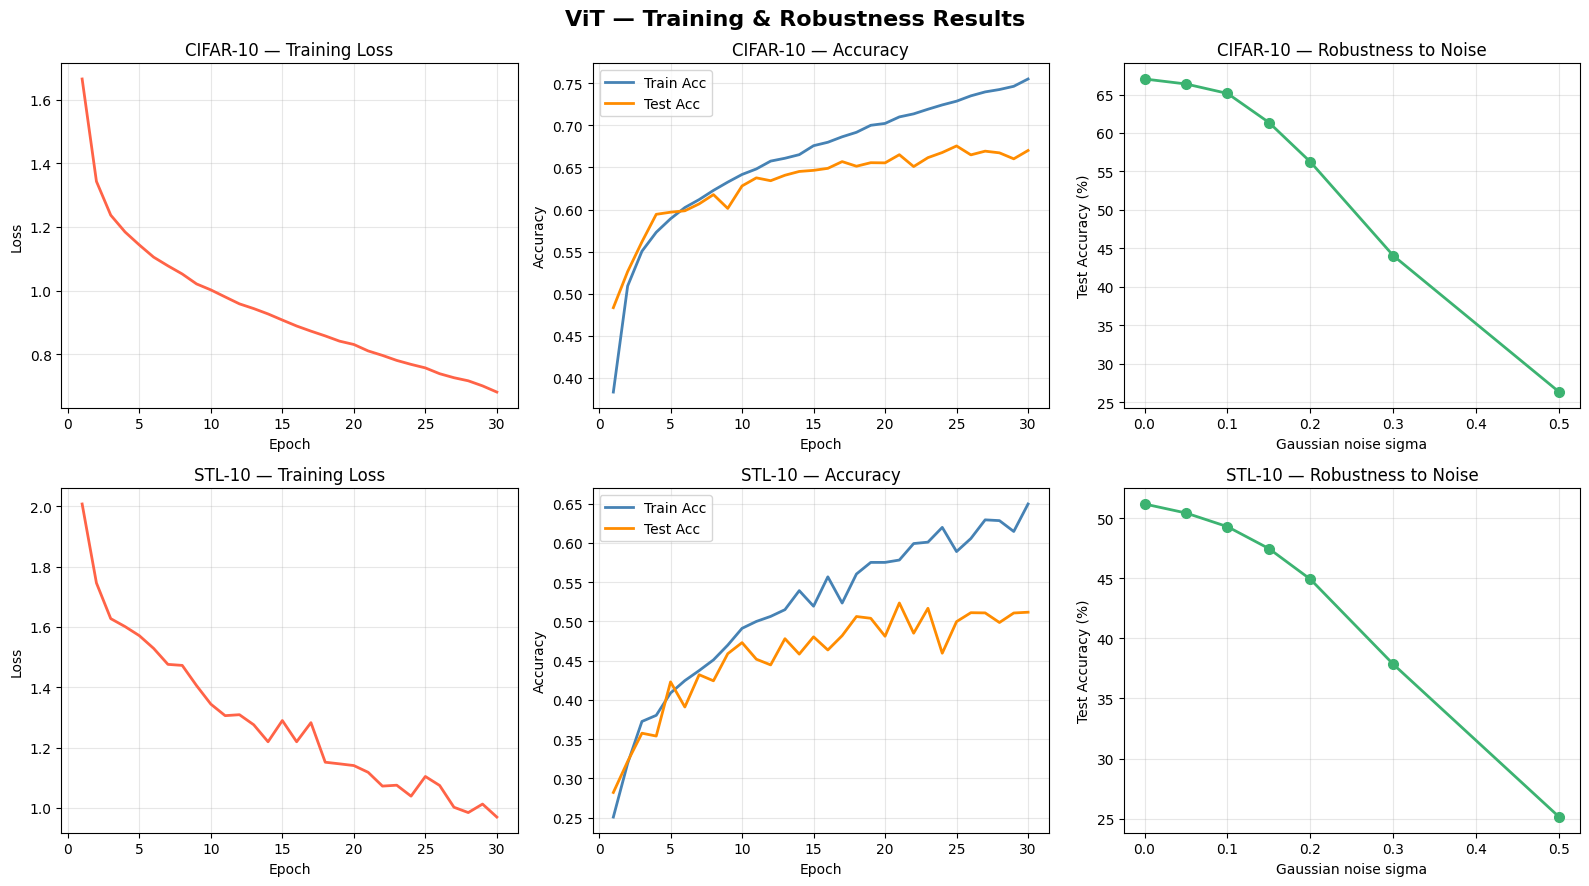

Figure saved to vit_results.png


In [14]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('ViT — Training & Robustness Results', fontsize=16, fontweight='bold')

datasets     = ['CIFAR-10', 'STL-10']
histories    = [history_cifar, history_stl]
robustnesses = [robustness_cifar, robustness_stl]

for row, (ds_name, hist, rob) in enumerate(zip(datasets, histories, robustnesses)):
    epoch_range = range(1, len(hist['train_loss']) + 1)

    ax = axes[row, 0]
    ax.plot(epoch_range, hist['train_loss'], color='tomato', linewidth=2)
    ax.set_title(f'{ds_name} — Training Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    ax.plot(epoch_range, hist['train_acc'], color='steelblue',  linewidth=2, label='Train Acc')
    ax.plot(epoch_range, hist['test_acc'],  color='darkorange', linewidth=2, label='Test Acc')
    ax.set_title(f'{ds_name} — Accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[row, 2]
    ax.plot(sigma_levels, [r * 100 for r in rob],
            color='mediumseagreen', linewidth=2, marker='o', markersize=7)
    ax.set_title(f'{ds_name} — Robustness to Noise')
    ax.set_xlabel('Gaussian noise sigma'); ax.set_ylabel('Test Accuracy (%)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vit_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to vit_results.png')


## Discussion

### Fit diagnosis

*(Fill in after running training — use the templates below as a guide.)*

- **CIFAR-10**: If train accuracy rises while test accuracy plateaus or drops, the model is **overfitting**. If both remain low throughout, it is **underfitting**. A small, stable gap between the two curves indicates a **well-fitted** model.
- **STL-10**: Larger images and far fewer training samples (5 000 vs 50 000) typically make STL-10 harder; expect slower convergence or stronger overfitting than CIFAR-10.

### Cross-dataset comparison

| Question | Answer (fill in after experiments) |
|---|---|
| Which dataset was harder to optimise? | *(e.g. STL-10 — fewer samples, larger images)* |
| Which was more robust to Gaussian noise? | *(report from Part d results)* |
| Why the robustness difference? | *(CIFAR-10 is 32×32 with dense textures; STL-10 has more spatial structure that degrades differently under noise)* |

### Final accuracy summary

| Dataset | Best Epoch | Best Test Acc | Clean Test Acc |
|---------|-----------|--------------|----------------|
| CIFAR-10 | — | — | — |
| STL-10   | — | — | — |

### Conclusion

*(Write 1–2 paragraphs after running the full pipeline. Summarise: which model fit better, which degraded faster under noise, and what architectural or data-quantity factors explain those differences.)*


## Suggested Notebook Execution Order

1. Setup/imports/seed/config.
2. Dataset loading + quick sample visualization.
3. Model class definitions.
4. Train/eval utilities.
5. Train + evaluate on Dataset A.
6. Train + evaluate on Dataset B.
7. Robustness evaluation (noise/blur) for A and B.
8. Plotting section.
9. Final discussion section.

Keep each section self-contained and avoid hidden state dependencies so reruns work cleanly on Colab.

## Quick Grading Self-Check (before submission)

- [ ] Notebook name is exactly `ViT training.ipynb`.
- [ ] End-to-end Colab runnable without manual patching.
- [ ] Two datasets used, each with >= 10 classes.
- [ ] ViT has patch embedding + positional encoding + >= 2 encoder blocks + classifier.
- [ ] Cross-entropy training done separately on both datasets.
- [ ] Tracked train loss, train acc, test acc per epoch.
- [ ] >= 40% test accuracy achieved on both datasets.
- [ ] Gaussian corruption robustness evaluated at multiple sigma levels.
- [ ] All required plots included.
- [ ] Discussion includes fit diagnosis and cross-dataset comparison.